# Assignment 2

You are provided with a preliminary dataset `data/preliminary_data.csv` from an insurance campaign. Before launching the full campaign and A/B testing it, you wish to determine the optimal sample size and ensure that the randomization process is robust.

The dataset contains:

- `user_id`
- `region`: the region where the user is from ("Norte", "Centro", "Lisboa", "Alentejo", "Algarve", "Madeira", "Azores")
- `age_group`: categorized age groups of the users ("18-25", "26-35", "36-45", "46-55", "56-65", "65+")
- `interacted`: if the user had any interaction with our preliminary campaign


In [137]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels
import scipy
import statsmodels.stats.api as sms
from statsmodels.stats.power import tt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import chi2_contingency

## Sample Size Determination:

1. Determine the baseline conversion rate using the preliminary data.
2. Use `statsmodels` to determine the required sample size for the A/B test, assuming you want to detect a 3% increase in the conversion rate with 80% power and a significance level of 5%.

In [138]:
preliminary_data = pd.read_csv('data/preliminary_data.csv')
display(preliminary_data.head())

,user_id,region,age_group,interacted
0,2d5b6d8b-f300-414e-a335-6d17eab60a19,Norte,65+,0
1,edf7488a-c19a-461e-93fe-d9b05ccdb057,Centro,26-35,0
2,b9c33d36-e3aa-469b-a667-fa102ea79cfa,Centro,26-35,0
3,fd0dc31b-621b-48a6-b5c1-224b2ba0da29,Alentejo,26-35,0
4,5d1eaf2f-fe45-4c3b-8786-cb28a41c48f3,Norte,26-35,0


In [139]:
baseline_conversion_rate = preliminary_data['interacted'].mean()
print(baseline_conversion_rate)

0.0289


In [140]:
def compute_sample_size(
        baseline_conversion_rate: float,
        minimum_detectable_effect: float,
        alpha: float = 0.05,
        power: float = 0.8):

    effect_size = sms.proportion_effectsize(
        baseline_conversion_rate,
        baseline_conversion_rate + minimum_detectable_effect
    )
    sample_size = (sms.NormalIndPower()
                   .solve_power(effect_size=effect_size,
                                alpha=alpha,
                                power=power,
                                ratio=1)
    )

    return int(round(sample_size))


In [141]:
minimum_detectable_effect = 0.03
alpha = 0.05
power = 0.8

sample_size = compute_sample_size(baseline_conversion_rate,
                                minimum_detectable_effect,
                                alpha,
                                power)
print(f"Sample size: {sample_size}")

total_sample_size = sample_size * 2


Sample size: 711


## Randomization Techniques:

Now that you know the approximate size of the sample, you can use to the `data/remaining_users.csv`, where you will have the rest of the users that you will use to design your A/B test. 

3. Propose two methods (don't forget to **only** select the number of users you computed in 2):
    * a method using `numpy` or `pandas` to randomly assign users to either Variant A or Variant B.
    * another method but now using `sklearn` ensuring an even distribution across `region` and `age_group`.
4. Create two functions in Python that, when given a dataset, returns a new dataset with an additional column variant indicating the variant assigned to each `user_id`.


In [142]:
remaining_users = pd.read_csv('data/remaining_users.csv')
display(remaining_users.head())
print(remaining_users.shape)

,user_id,region,age_group
0,6e7d8fcf-eb6f-429c-b8c8-07d5eb3da5ee,Norte,36-45
1,088efb0f-bd91-4e21-8698-52568a9f388c,Lisboa,56-65
2,87f25898-8c2a-4a82-8bd7-f38e82a1807a,Centro,46-55
3,8ef72197-d8e9-47e0-a9dd-03d7e3f27de4,Norte,26-35
4,cca4971a-d966-4e54-a04e-7b25c9691024,Norte,65+


(100000, 3)


In [143]:
def random_assign_variant(df, sample_size):
    df = df.sample(sample_size, random_state=42)
    df['variant'] = np.random.choice(['A', 'B'], size=sample_size)
    return df

random_assign_variant(remaining_users, sample_size=total_sample_size)


,user_id,region,age_group,variant
75721,4a09bb73-2865-4102-ae16-eae53793d99b,Lisboa,26-35,B
80184,e46583de-0ebe-4d30-8ce1-364ae8a8d893,Alentejo,18-25,B
19864,57cb3cae-5c25-4505-9eed-3b8a64284371,Norte,18-25,B
76699,fc7b05f2-1532-47dc-90af-5b4527680db3,Lisboa,26-35,A
92991,4a39df91-22eb-4433-a9c9-d957596332d3,Lisboa,65+,B
...,...,...,...,...
22096,71546f69-d242-4e46-b245-e5ea114d86dd,Lisboa,36-45,B
1165,cf181028-b05e-4144-9318-90252f3dbf44,Norte,65+,A
94931,c610b4cc-d522-443c-9c1a-82ae7d620ea5,Lisboa,36-45,A
84935,fbe83e44-00d5-418a-b3f6-63e007053d5d,Norte,46-55,B


In [144]:
def random_assign_variant_sklearn(df, sample_size):
    df_sample = df.sample(sample_size, random_state=42).copy()
    
    df_sample['stratify_col'] = df_sample['region'] + '_' + df_sample['age_group']
    
    # Check if all combinations have at least 2 members (required for stratification)
    stratify_counts = df_sample['stratify_col'].value_counts()
    if (stratify_counts < 2).any():
        stratify_col = df_sample['region']
    else:
        stratify_col = df_sample['stratify_col']
    
    idx_A, idx_B = train_test_split(df_sample.index,
                                test_size=0.5,
                                stratify=stratify_col,
                                random_state=42)

    df_sample.loc[idx_A, 'variant'] = 'A'
    df_sample.loc[idx_B, 'variant'] = 'B'

    return df_sample.drop(columns=['stratify_col'])


## Data Integrity:

5. After randomization, compare both approaches by visualizing the distributions of users across the variants for each `region` and `age_group`. Which method seems more appropriate?


In [145]:

def plot_variants_distribution(df, col_name:str):

    # 1. Get the counts of variants for each group
    df_counts = pd.crosstab(df[col_name], df['variant'])

    # 2. Normalize by row to get proportions (percentages)
    #    This divides each row by its sum
    df_props = df_counts.div(df_counts.sum(axis=1), axis=0)

    # 3. Plot the 100% stacked bar chart
    ax = df_props.plot(
        kind='bar', 
        stacked=True, 
        figsize=(10, 6),
        rot=0,  # Keep region labels horizontal
        title=f'Proportion of Variants within Each {col_name}'
    )

    # Add a horizontal line at 50% for easy reference
    ax.axhline(0.5, color='grey', linestyle='--', label='50% Split')

    ax.set_ylabel("Proportion of Users")
    ax.set_xlabel(col_name)

    # Place the legend outside the plot
    ax.legend(title='Variant', loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

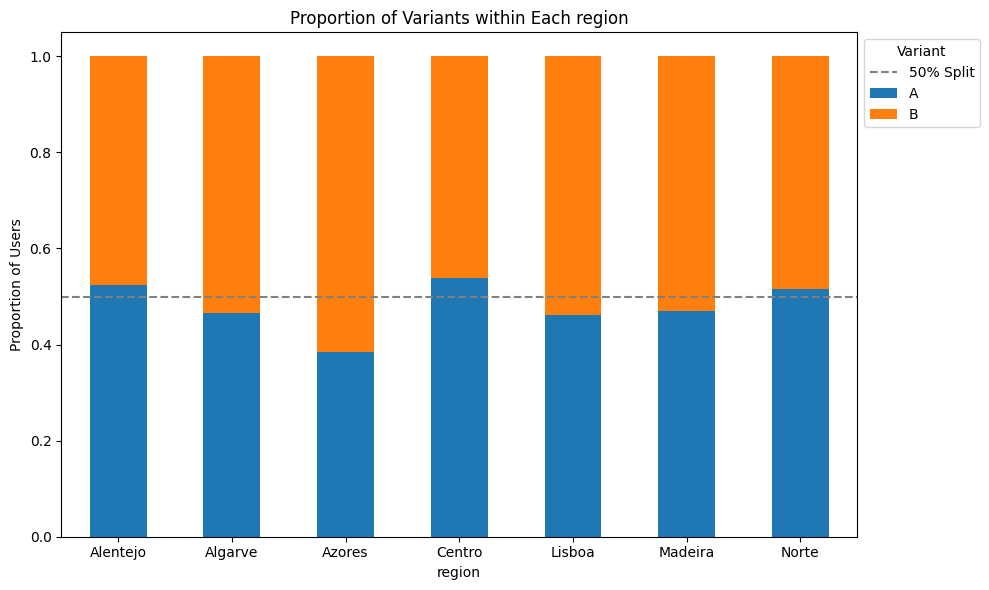

In [146]:
users_np_randomization = random_assign_variant(remaining_users,
                                                sample_size=total_sample_size)

plot_variants_distribution(users_np_randomization, 'region')


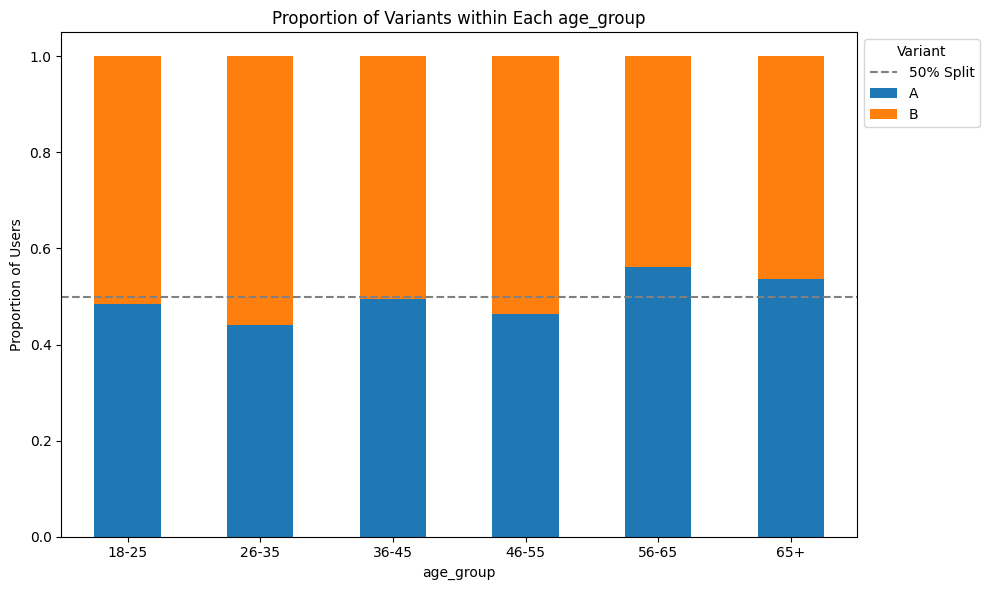

In [147]:
plot_variants_distribution(users_np_randomization, 'age_group')

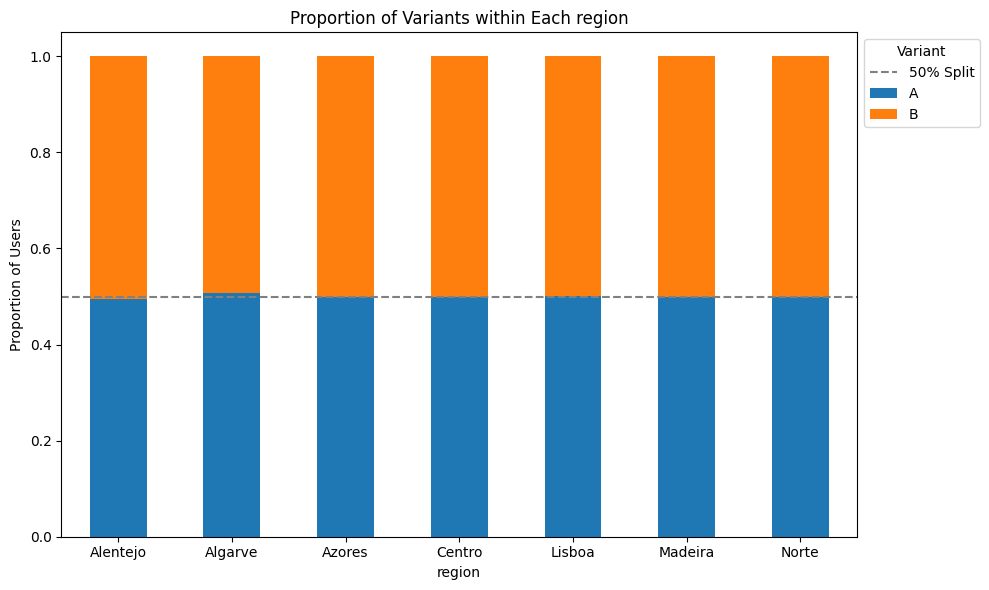

In [148]:
users_sklearn_randomization = random_assign_variant_sklearn(remaining_users,
                                                         sample_size=total_sample_size)

plot_variants_distribution(users_sklearn_randomization, 'region')

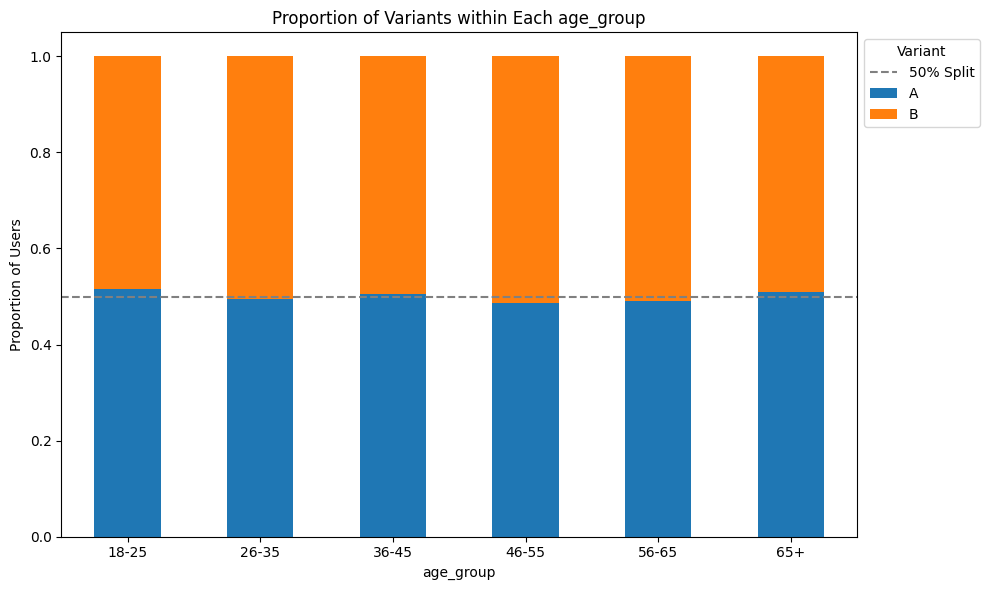

In [149]:
plot_variants_distribution(users_sklearn_randomization, 'age_group')

## Preliminary Testing:

6. Using the functions designed in step 4, assign variants to the users in the `remaining_users.csv`. The column should be called `version` and the versions should be called `A` and `B`. 
7. We have prepare the function `get_results` in the `results_generator/run_experiment.py`. You only need to import it and pass your dataframe to it, like so `get_results(df)`. Calculate the conversion rate for both Variant A and Variant B from this preliminary test. Discuss if the results are statistically significant or if further testing with a larger sample is necessary.


In [150]:
df_all = random_assign_variant_sklearn(remaining_users, total_sample_size)
df_all.rename(columns={'variant': 'version'}, inplace=True)
df_all.head()

,user_id,region,age_group,version
75721,4a09bb73-2865-4102-ae16-eae53793d99b,Lisboa,26-35,B
80184,e46583de-0ebe-4d30-8ce1-364ae8a8d893,Alentejo,18-25,A
19864,57cb3cae-5c25-4505-9eed-3b8a64284371,Norte,18-25,B
76699,fc7b05f2-1532-47dc-90af-5b4527680db3,Lisboa,26-35,A
92991,4a39df91-22eb-4433-a9c9-d957596332d3,Lisboa,65+,B


In [151]:
from results_generator.run_experiment import get_results

results = get_results(df_all)
display(results.head())
results.shape

,user_id,region,age_group,version,interacted
75721,4a09bb73-2865-4102-ae16-eae53793d99b,Lisboa,26-35,B,0
80184,e46583de-0ebe-4d30-8ce1-364ae8a8d893,Alentejo,18-25,A,0
19864,57cb3cae-5c25-4505-9eed-3b8a64284371,Norte,18-25,B,0
76699,fc7b05f2-1532-47dc-90af-5b4527680db3,Lisboa,26-35,A,0
92991,4a39df91-22eb-4433-a9c9-d957596332d3,Lisboa,65+,B,0


(1422, 5)

In [152]:
df_counts = pd.crosstab(results['version'], results['interacted'])
df_props = df_counts.div(df_counts.sum(axis=1), axis=0)
display(df_props)

success_rates = df_props[1] 

A_success_rate = success_rates.loc['A']
B_success_rate = success_rates.loc['B']

print(f"A Success Rate: {A_success_rate:.2%}")
print(f"B Success Rate: {B_success_rate:.2%}")

interacted,0,1
version,,
A,0.973277,0.026723
B,0.925457,0.074543


A Success Rate: 2.67%
B Success Rate: 7.45%


In [153]:
# Run the Chi-Squared Test
chi2, p_value, dof, expected = chi2_contingency(df_counts)

print(f"\nChi-Squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

# results
if p_value < alpha:
    print("\nThe results ARE statistically significant (p < 0.05).")
    print("This suggests Version B is truly better than Version A.")
else:
    print("\nThe results are NOT statistically significant (p > 0.05).")
    print("We cannot conclude that Version B is better. The difference is likely due to random chance.")

print("\nDiscussion: Given this is a preliminary test, the sample size is likely small.")
print("Even if significant, we should run a larger, properly powered test to confirm these findings.")


Chi-Squared Statistic: 15.9317
P-value: 0.0001

The results ARE statistically significant (p < 0.05).
This suggests Version B is truly better than Version A.

Discussion: Given this is a preliminary test, the sample size is likely small.
Even if significant, we should run a larger, properly powered test to confirm these findings.
